# Zomato Restaurant Dataset — Assessment

**Part 1** Data quality · **Part 2** Exploratory analysis · **Part 3** What drives ratings?

Source: `Zomato Restaurant Dataset.csv` (same folder).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)

# Part 1 — Data quality
## 1.1 Load

In [2]:
raw = pd.read_csv("Zomato Restaurant Dataset.csv", encoding="utf-8-sig")
assert len(raw) == 9551, len(raw)
print(raw.shape)
raw.dtypes.to_frame("dtype").T

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
dtype,int64,str,int64,str,str,str,str,float64,float64,str,int64,str,str,str,str,str,int64,float64,str,str,int64


In [3]:
raw.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 1.2 Column-level profile

In [4]:
def profile(df):
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "blank_strings": df.apply(lambda s: (s.astype(str).str.strip() == "").sum() if not pd.api.types.is_numeric_dtype(s) else 0),
        "zeros": df.apply(lambda s: (s == 0).sum() if pd.api.types.is_numeric_dtype(s) else 0),
        "unique": df.nunique(dropna=False),
    })
    out["constant"] = out["unique"] == 1
    return out

profile(raw)

,dtype,nulls,blank_strings,zeros,unique,constant
Restaurant ID,int64,0,0,0,9551,False
Restaurant Name,str,0,0,0,7446,False
Country Code,int64,0,0,0,15,False
City,str,0,0,0,141,False
Address,str,0,0,0,8918,False
Locality,str,0,0,0,1208,False
Locality Verbose,str,0,0,0,1265,False
Longitude,float64,0,0,498,8120,False
Latitude,float64,0,0,498,8677,False
Cuisines,str,9,0,0,1826,False


## 1.3 Specific issues

In [5]:
issues = {
    "Duplicate Restaurant IDs": raw["Restaurant ID"].duplicated().sum(),
    "Fully duplicated rows": raw.duplicated().sum(),
    "Aggregate rating == 0 ('Not rated')": (raw["Aggregate rating"] == 0).sum(),
    "Average Cost for two == 0": (raw["Average Cost for two"] == 0).sum(),
    "Latitude/Longitude == 0": ((raw["Latitude"] == 0) | (raw["Longitude"] == 0)).sum(),
    "Blank Cuisines": raw["Cuisines"].isna().sum(),
    "Constant column 'Switch to order menu'": raw["Switch to order menu"].nunique() == 1,
    "Repeated restaurant names (chains/branches)": raw["Restaurant Name"].duplicated(keep=False).sum(),
}
pd.Series(issues, name="count").to_frame()

,count
Duplicate Restaurant IDs,0
Fully duplicated rows,0
Aggregate rating == 0 ('Not rated'),2148
Average Cost for two == 0,18
Latitude/Longitude == 0,499
Blank Cuisines,9
Constant column 'Switch to order menu',True
Repeated restaurant names (chains/branches),2839


**Rating 0 vs "Not rated"** — check that they are the same rows:

In [6]:
pd.crosstab(raw['Aggregate rating'] == 0, raw['Rating text'] == 'Not rated')

Rating text,False,True
Aggregate rating,,
False,7403,0
True,0,2148


**Currency labels.** The file has no country names, and each currency is keyed to a country code.
Two labels are wrong:
* Country **162** is the Philippines, but its currency is labelled *Botswana Pula(P)*.
* The UK's pound sign was lost before the file was saved. The file contains two U+FFFD replacement characters, so it shows as `Pounds(��)`.

In [7]:
raw.groupby(['Country Code', 'Currency']).size().rename('rows').reset_index()

,Country Code,Currency,rows
0,1,Indian Rupees(Rs.),8652
1,14,Dollar($),24
2,30,Brazilian Real(R$),60
3,37,Dollar($),4
4,94,Indonesian Rupiah(IDR),21
5,148,NewZealand($),40
6,162,Botswana Pula(P),22
7,166,Qatari Rial(QR),20
8,184,Dollar($),20
9,189,Rand(R),60


**Broken text (mojibake).** Accented characters were already replaced with U+FFFD (`�`) in the file itself, so they can't be recovered by re-decoding.
This affects Brazilian and Turkish text across many columns. Only the three affected **city** names are fixed by hand, because they are used for grouping.

In [8]:
text_cols = raw.columns[~raw.dtypes.map(pd.api.types.is_numeric_dtype)]
bad = {c: raw[c].astype(str).str.contains("\ufffd") for c in text_cols}
display(pd.Series({c: m.sum() for c, m in bad.items() if m.any()}, name="rows with U+FFFD").to_frame())
display(raw.loc[bad["City"], ["Country Code", "City"]].value_counts())

,rows with U+FFFD
Restaurant Name,103
City,54
Address,89
Locality,34
Locality Verbose,66
Cuisines,2
Currency,80


Country Code  City      
30            Bras�_lia     20
              S��o Paulo    20
208           ��stanbul     14
Name: count, dtype: int64

**Outliers (IQR rule, within each country because currencies differ)**

In [9]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    return ((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum()

pd.DataFrame({
    "cost_outliers": raw.groupby("Country Code")["Average Cost for two"].apply(iqr_outliers),
    "votes_outliers": raw.groupby("Country Code")["Votes"].apply(iqr_outliers),
    "rows": raw.groupby("Country Code").size(),
})

,cost_outliers,votes_outliers,rows
Country Code,,,
1,813,1048,8652
14,10,0,24
30,2,2,60
37,1,0,4
94,2,0,21
148,2,4,40
162,2,1,22
166,2,0,20
184,0,0,20


In [10]:
raw.nlargest(5, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']]

,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6


## 1.4 Cleaning

| Step | Why |
|---|---|
| Map country code → name | The country lookup file isn't included, so the standard Zomato mapping is hardcoded |
| Fix currency labels | Correct the Philippines mislabel and the broken £ symbol |
| Fix 3 broken city names | Brasília, São Paulo, İstanbul, for grouping. Other broken text is left as-is |
| Yes/No → bool | Makes the columns easier to analyse |
| Drop `Switch to order menu` | It has only one value, so it carries no information |
| Rating 0 → NaN | 0 means *not rated*. It is not a real score and would drag down means |
| Cost 0, lat/lon 0 → NaN | These are placeholders for missing values |
| Parse `Cuisines` | Gives a list, a count and the primary (first-listed) cuisine |
| `cost_usd` | Makes costs comparable across countries. It uses **approximate, static** FX rates |

In [11]:
COUNTRY = {1: "India", 14: "Australia", 30: "Brazil", 37: "Canada", 94: "Indonesia",
           148: "New Zealand", 162: "Philippines", 166: "Qatar", 184: "Singapore",
           189: "South Africa", 191: "Sri Lanka", 208: "Turkey", 214: "UAE",
           215: "United Kingdom", 216: "United States"}
# (currency label, approx. USD per 1 unit) keyed by country code — static, indicative only
FX = {1: ("Indian Rupees(Rs.)", 0.012), 14: ("Dollar($)", 0.66), 30: ("Brazilian Real(R$)", 0.19),
      37: ("Dollar($)", 0.73), 94: ("Indonesian Rupiah(IDR)", 0.000063), 148: ("NewZealand($)", 0.60),
      162: ("Philippine Peso(PHP)", 0.018), 166: ("Qatari Rial(QR)", 0.275), 184: ("Dollar($)", 0.76),
      189: ("Rand(R)", 0.055), 191: ("Sri Lankan Rupee(LKR)", 0.0033), 208: ("Turkish Lira(TL)", 0.03),
      214: ("Emirati Diram(AED)", 0.272), 215: ("Pounds(£)", 1.3), 216: ("Dollar($)", 1.0)}
assert set(raw["Country Code"]) <= set(COUNTRY)

df = raw.rename(columns=lambda c: c.strip().lower().replace(" ", "_")).drop(columns="switch_to_order_menu")
df["country"] = df["country_code"].map(COUNTRY)
df["city"] = df["city"].replace({"Bras\ufffd_lia": "Brasília", "S\ufffd\ufffdo Paulo": "São Paulo", "\ufffd\ufffdstanbul": "İstanbul"})
assert not df["city"].str.contains("\ufffd").any()
df["currency"] = df["country_code"].map(lambda c: FX[c][0])
for c in ["has_table_booking", "has_online_delivery", "is_delivering_now"]:
    df[c] = df[c].eq("Yes")

df["rating"] = df["aggregate_rating"].replace(0, np.nan)
df["cost_local"] = df["average_cost_for_two"].replace(0, np.nan)
df["cost_usd"] = df["cost_local"] * df["country_code"].map(lambda c: FX[c][1])
bad_geo = (df["latitude"] == 0) | (df["longitude"] == 0)
df.loc[bad_geo, ["latitude", "longitude"]] = np.nan

df["cuisine_list"] = df["cuisines"].fillna("").str.split(r"\s*,\s*").apply(lambda l: [x for x in l if x])
df["n_cuisines"] = df["cuisine_list"].str.len()
df["primary_cuisine"] = df["cuisine_list"].str[0]
df["log_votes"] = np.log1p(df["votes"])
df["rated"] = df["rating"].notna()

rated = df[df["rated"]].copy()
assert len(rated) == 7403, len(rated)
print(f"All rows: {len(df):,} | rated: {len(rated):,} | unrated: {(~df.rated).sum():,}")

All rows: 9,551 | rated: 7,403 | unrated: 2,148


## 1.5 Data-quality summary

In [12]:
print(f'''
* {len(df):,} restaurants, {df.country.nunique()} countries, {df.city.nunique()} cities. No duplicate IDs.
* {(~df.rated).sum():,} ({(~df.rated).mean():.0%}) are unrated (rating 0 / "Not rated"). They are left out of rating analysis.
* {df.cost_local.isna().sum()} zero costs, {bad_geo.sum()} zero coordinates, {df.cuisines.isna().sum()} blank cuisines were set to NaN.
* Two currency labels are wrong (Philippines as Botswana Pula; broken £). Both are fixed.
* Accented characters in Brazilian/Turkish text were lost (U+FFFD) and can't be recovered. City names are fixed; names and addresses are left as-is.
* Costs use 12 currencies. Raw costs can only be compared within one country. `cost_usd` is approximate.
* Heavy skew: India is {(df.country=="India").mean():.0%} of rows and New Delhi alone is {(df.city=="New Delhi").mean():.0%}.
''')


* 9,551 restaurants, 15 countries, 141 cities. No duplicate IDs.
* 2,148 (22%) are unrated (rating 0 / "Not rated"). They are left out of rating analysis.
* 18 zero costs, 499 zero coordinates, 9 blank cuisines were set to NaN.
* Two currency labels are wrong (Philippines as Botswana Pula; broken £). Both are fixed.
* Accented characters in Brazilian/Turkish text were lost (U+FFFD) and can't be recovered. City names are fixed; names and addresses are left as-is.
* Costs use 12 currencies. Raw costs can only be compared within one country. `cost_usd` is approximate.
* Heavy skew: India is 91% of rows and New Delhi alone is 57%.



# Part 2 — Exploratory analysis
## 2.1 Geography

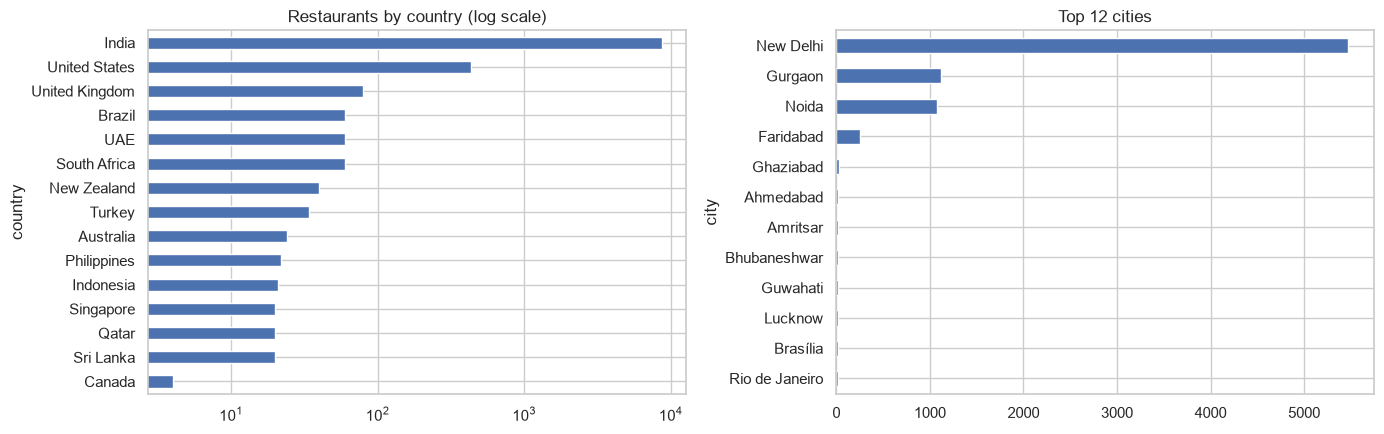

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
df["country"].value_counts().plot.barh(ax=ax[0], title="Restaurants by country (log scale)", logx=True).invert_yaxis()
df["city"].value_counts().head(12).plot.barh(ax=ax[1], title="Top 12 cities").invert_yaxis()
plt.tight_layout()

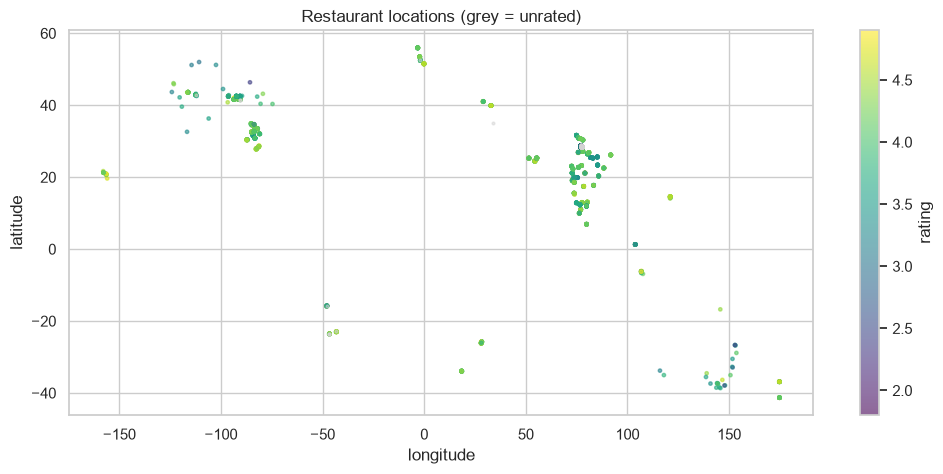

In [14]:
geo = df.dropna(subset=["latitude", "longitude"])
fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(geo.longitude, geo.latitude, c=geo.rating, s=6, cmap="viridis", alpha=.6)
plt.colorbar(sc, label="rating"); ax.set_title("Restaurant locations (grey = unrated)")
ax.scatter(geo[~geo.rated].longitude, geo[~geo.rated].latitude, s=4, c="lightgrey", alpha=.5)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude");

## 2.2 Distributions

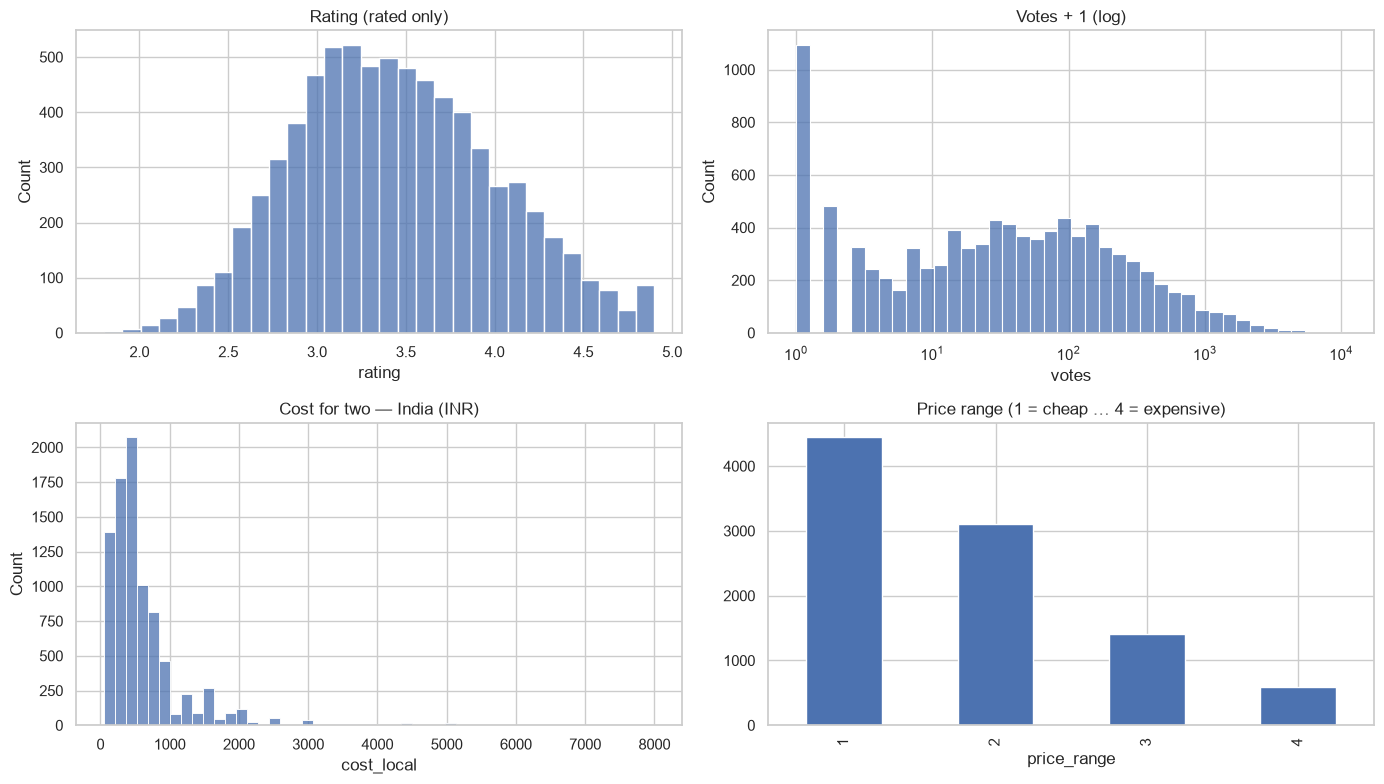

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
sns.histplot(rated.rating, bins=30, ax=ax[0, 0]).set_title("Rating (rated only)")
sns.histplot(df.votes + 1, log_scale=True, bins=40, ax=ax[0, 1]).set_title("Votes + 1 (log)")
sns.histplot(df[df.country == "India"].cost_local, bins=50, ax=ax[1, 0]).set_title("Cost for two — India (INR)")
df.price_range.value_counts().sort_index().plot.bar(ax=ax[1, 1], title="Price range (1 = cheap … 4 = expensive)")
plt.tight_layout()

In [16]:
df[['rating', 'votes', 'cost_usd', 'price_range', 'n_cuisines']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rating,7403.0,3.44,0.55,1.8,3.0,3.4,3.8,4.9
votes,9551.0,156.91,430.17,0.0,5.0,31.0,131.0,10934.0
cost_usd,9533.0,9.83,14.25,0.6,3.6,6.0,10.0,380.0
price_range,9551.0,1.80,0.91,1.0,1.0,2.0,2.0,4.0
n_cuisines,9551.0,2.06,1.09,0.0,1.0,2.0,3.0,8.0


In [17]:
# Is price_range consistent with cost_usd?
df.groupby("price_range")["cost_usd"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
price_range,,,,,,,,
1,4426.0,3.6,1.7,0.6,2.4,3.6,4.8,19.5
2,3113.0,8.7,5.0,0.9,6.0,7.2,8.4,45.5
3,1408.0,18.6,10.8,1.8,12.0,15.6,19.2,78.0
4,586.0,41.7,37.0,3.6,24.0,30.0,48.0,380.0


## 2.3 Cuisines

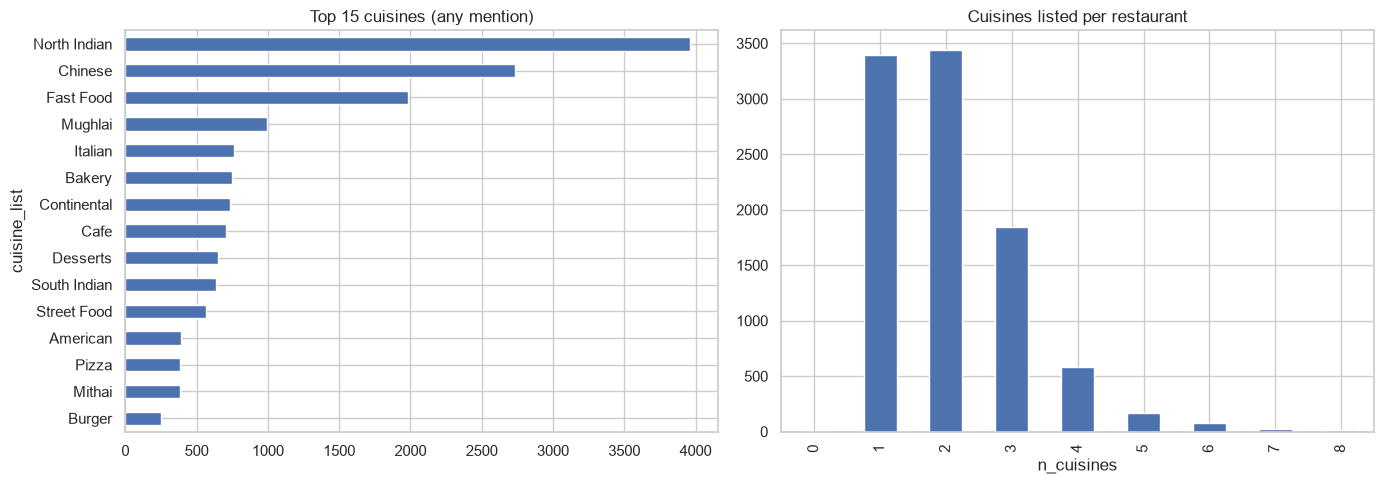

In [18]:
exploded = df.explode("cuisine_list")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
exploded.cuisine_list.value_counts().head(15).plot.barh(ax=ax[0], title="Top 15 cuisines (any mention)").invert_yaxis()
df.n_cuisines.value_counts().sort_index().plot.bar(ax=ax[1], title="Cuisines listed per restaurant")
plt.tight_layout()

## 2.4 Delivery & table booking

In [19]:
svc = df.groupby("country")[["has_online_delivery", "has_table_booking", "is_delivering_now"]].mean().mul(100).round(1)
svc.assign(rows=df.groupby("country").size()).sort_values("rows", ascending=False)

,has_online_delivery,has_table_booking,is_delivering_now,rows
country,,,,
India,28.0,12.8,0.4,8652
United States,0.0,0.0,0.0,434
United Kingdom,0.0,15.0,0.0,80
Brazil,0.0,0.0,0.0,60
South Africa,0.0,3.3,0.0,60
UAE,46.7,30.0,0.0,60
New Zealand,0.0,0.0,0.0,40
Turkey,0.0,0.0,0.0,34
Australia,0.0,0.0,0.0,24


In [20]:
top_in_cities = df[df.country == "India"].city.value_counts().head(8).index
(df[df.city.isin(top_in_cities)].groupby("city")[["has_online_delivery", "has_table_booking"]]
   .mean().mul(100).round(1).sort_values("has_online_delivery", ascending=False))

,has_online_delivery,has_table_booking
city,,
Ahmedabad,52.4,0.0
Ghaziabad,40.0,12.0
Gurgaon,38.0,18.2
Noida,33.7,10.4
New Delhi,27.2,13.1
Faridabad,13.9,6.0
Amritsar,0.0,0.0
Bhubaneshwar,0.0,0.0


## 2.5 Rating text vs numeric rating (consistency check)

In [21]:
bands = df.groupby("rating_text")["aggregate_rating"].agg(["min", "max", "count"]).sort_values("min")
display(bands)
display(pd.crosstab(df.rating_text, df.rating_color))

,min,max,count
rating_text,,,
Not rated,0.0,0.0,2148
Poor,1.8,2.4,186
Average,2.5,3.4,3737
Good,3.5,3.9,2100
Very Good,4.0,4.4,1079
Excellent,4.5,4.9,301


rating_color,Dark Green,Green,Orange,Red,White,Yellow
rating_text,,,,,,
Average,0,0,3737,0,0,0
Excellent,301,0,0,0,0,0
Good,0,0,0,0,0,2100
Not rated,0,0,0,0,2148,0
Poor,0,0,0,186,0,0
Very Good,0,1079,0,0,0,0


# Part 3 — What drives ratings?
Rated restaurants only (n = 7,403). All results are **associations** from observational data, not causal effects.
## 3.1 Univariate views

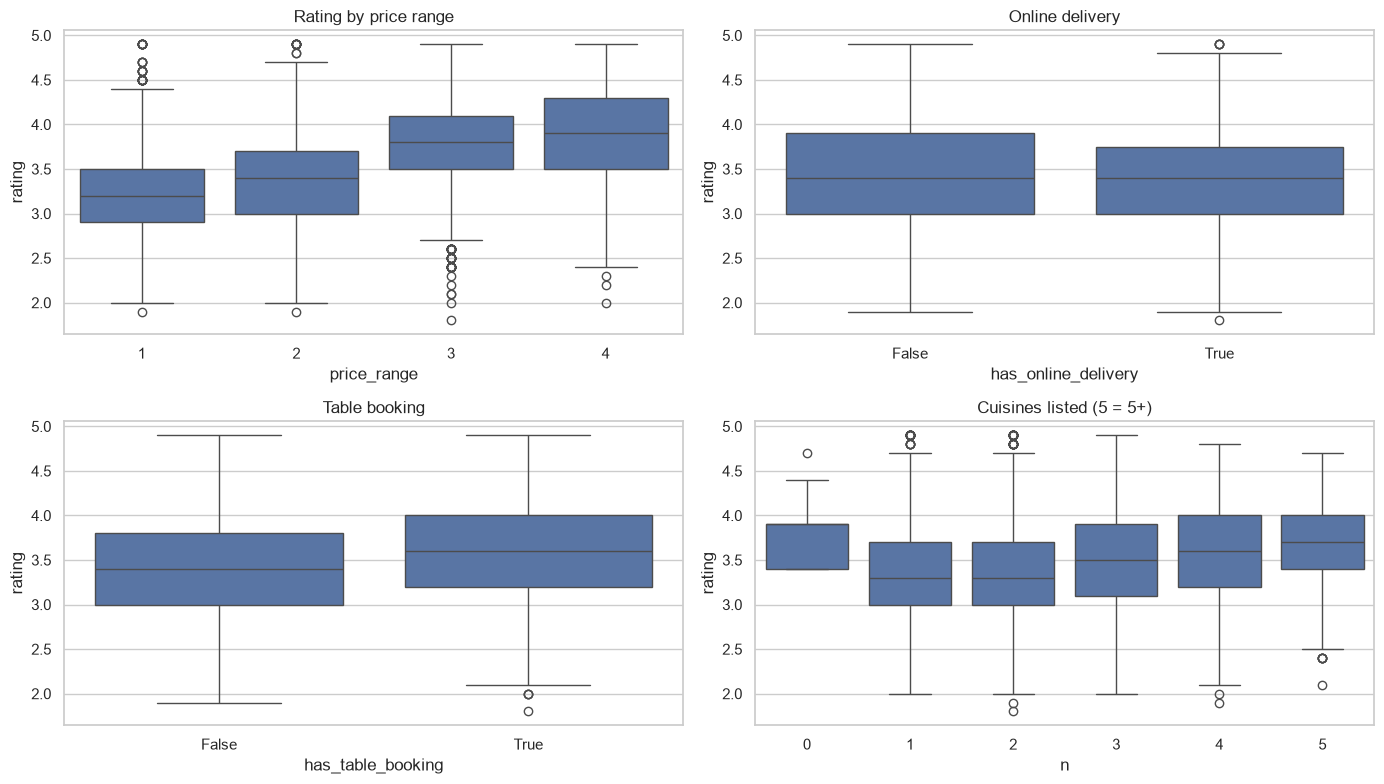

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=rated, x="price_range", y="rating", ax=ax[0, 0]).set_title("Rating by price range")
sns.boxplot(data=rated, x="has_online_delivery", y="rating", ax=ax[0, 1]).set_title("Online delivery")
sns.boxplot(data=rated, x="has_table_booking", y="rating", ax=ax[1, 0]).set_title("Table booking")
sns.boxplot(data=rated.assign(n=rated.n_cuisines.clip(upper=5)), x="n", y="rating", ax=ax[1, 1]).set_title("Cuisines listed (5 = 5+)")
plt.tight_layout()

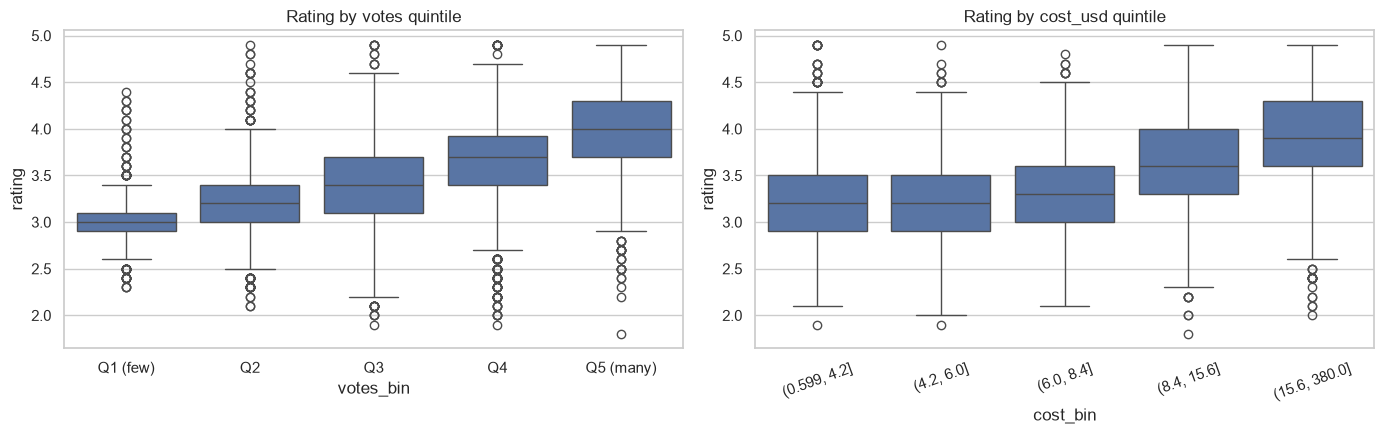

In [23]:
rated["votes_bin"] = pd.qcut(rated.votes, 5, labels=["Q1 (few)", "Q2", "Q3", "Q4", "Q5 (many)"])
rated["cost_bin"] = pd.qcut(rated.cost_usd, 5, duplicates="drop")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=rated, x="votes_bin", y="rating", ax=ax[0]).set_title("Rating by votes quintile")
sns.boxplot(data=rated, x="cost_bin", y="rating", ax=ax[1]).set_title("Rating by cost_usd quintile")
ax[1].tick_params(axis="x", rotation=20); plt.tight_layout()

In [24]:
def group_table(col, min_n=30, top=12):
    g = rated.groupby(col)["rating"].agg(["mean", "median", "count"])
    return g[g["count"] >= min_n].sort_values("mean", ascending=False).round(2)

print("Primary cuisine (n >= 30), highest and lowest:")
pc = group_table("primary_cuisine")
display(pd.concat([pc.head(8), pc.tail(5)]))
print("Cities (n >= 30):")
display(group_table("city"))

Primary cuisine (n >= 30), highest and lowest:


,mean,median,count
primary_cuisine,,,
Indian,4.18,4.20,50
Seafood,4.06,4.00,48
European,4.02,4.10,60
Asian,3.93,4.05,72
Mexican,3.92,3.90,59
Japanese,3.82,3.80,71
Continental,3.77,3.80,225
Burger,3.71,3.70,107
Chinese,3.27,3.20,608


Cities (n >= 30):


,mean,median,count
city,,,
Gurgaon,3.33,3.3,890
New Delhi,3.30,3.3,4048
Noida,3.16,3.1,696
Faridabad,3.10,3.0,151


In [25]:
# Cuisine by *any* mention: difference in mean rating vs. restaurants without that cuisine
ex = rated.explode("cuisine_list")
top_cuisines = ex.cuisine_list.value_counts().head(20).index
lift = pd.DataFrame({c: {
    "n": rated.cuisine_list.apply(lambda l: c in l).sum(),
    "mean_with": rated.loc[rated.cuisine_list.apply(lambda l: c in l), "rating"].mean(),
    "mean_without": rated.loc[~rated.cuisine_list.apply(lambda l: c in l), "rating"].mean()} for c in top_cuisines}).T
lift["lift"] = lift.mean_with - lift.mean_without
lift.sort_values("lift", ascending=False).round(3)

,n,mean_with,mean_without,lift
Seafood,171.0,3.930,3.428,0.501
Asian,228.0,3.899,3.425,0.473
Mexican,174.0,3.873,3.430,0.443
Italian,726.0,3.748,3.406,0.342
American,380.0,3.758,3.423,0.335
Thai,229.0,3.740,3.430,0.309
Continental,699.0,3.705,3.412,0.293
Burger,239.0,3.697,3.431,0.266
Cafe,634.0,3.683,3.417,0.265
Desserts,543.0,3.582,3.429,0.154


## 3.2 Correlations & significance tests

In [26]:
rows = []
for col in ["log_votes", "cost_usd", "price_range", "n_cuisines"]:
    d = rated[[col, "rating"]].dropna()
    rho, p = stats.spearmanr(d[col], d["rating"])
    rows.append((col, rho, p, len(d)))
pd.DataFrame(rows, columns=["feature", "spearman_rho", "p", "n"]).set_index("feature").round(4)

,spearman_rho,p,n
feature,,,
log_votes,0.6821,0.0,7403
cost_usd,0.4414,0.0,7385
price_range,0.4017,0.0,7403
n_cuisines,0.1157,0.0,7403


In [27]:
tests = []
for col in ["has_online_delivery", "has_table_booking"]:
    a, b = rated.loc[rated[col], "rating"], rated.loc[~rated[col], "rating"]
    u, p = stats.mannwhitneyu(a, b)
    tests.append((f"Mann-Whitney: {col}", a.mean() - b.mean(), p))
for col in ["price_range", "city"]:
    groups = [g.values for _, g in rated.groupby(col)["rating"] if len(g) >= 10]
    h, p = stats.kruskal(*groups)
    tests.append((f"Kruskal-Wallis: {col}", h, p))
pd.DataFrame(tests, columns=["test", "effect (mean diff / H)", "p"]).set_index("test")

,effect (mean diff / H),p
test,,
Mann-Whitney: has_online_delivery,-0.086159,8.662605e-04
Mann-Whitney: has_table_booking,0.173609,1.552683e-27
Kruskal-Wallis: price_range,1326.066564,3.249781e-287
Kruskal-Wallis: city,2382.045968,0.000000e+00


## 3.3 Multivariable model (OLS)
Rating is modelled on price range, delivery, booking, cuisine count and primary cuisine (top 12, others grouped), with country and city (top 10, others grouped) as fixed effects.
**Votes is modelled separately.** It is partly an *outcome* of quality (good places attract reviews), so including it absorbs much of the other effects.

In [28]:
def prep(d):
    d = d.copy()
    top_c = d.primary_cuisine.value_counts().head(12).index
    d["cuisine_grp"] = d.primary_cuisine.where(d.primary_cuisine.isin(top_c), "Other")
    top_city = d.city.value_counts().head(10).index
    d["city_grp"] = d.city.where(d.city.isin(top_city), "Other")
    for c in ["has_online_delivery", "has_table_booking"]:
        d[c] = d[c].astype(int)
    return d

m = prep(rated)
base = ("rating ~ C(price_range) + has_online_delivery + has_table_booking + n_cuisines"
        " + C(cuisine_grp, Treatment('Other')) + C(country, Treatment('India')) + C(city_grp, Treatment('Other'))")
ols_a = smf.ols(base, data=m).fit(cov_type="HC3")
ols_b = smf.ols(base + " + log_votes", data=m).fit(cov_type="HC3")
print(f"Model A (no votes): R² = {ols_a.rsquared:.3f}   |   Model B (+ log_votes): R² = {ols_b.rsquared:.3f}")

Model A (no votes): R² = 0.429   |   Model B (+ log_votes): R² = 0.580


In [29]:
def coef_table(res):
    t = pd.DataFrame({"coef": res.params, "ci_low": res.conf_int()[0], "ci_high": res.conf_int()[1], "p": res.pvalues})
    return t.drop("Intercept").round(3)

key = [i for i in ols_a.params.index if not i.startswith(("C(country", "C(city_grp"))]
pd.concat({"A: no votes": coef_table(ols_a).loc[key[1:]], "B: + log_votes": coef_table(ols_b).loc[key[1:] + ["log_votes"]]}, axis=1)

A: no votes                       B: + log_votes                      
                                                          coef ci_low ci_high      p           coef ci_low ci_high      p
C(price_range)[T.2]                                      0.072  0.047   0.096  0.000         -0.021 -0.043   0.000  0.053
C(price_range)[T.3]                                      0.268  0.228   0.309  0.000          0.042  0.007   0.077  0.017
C(price_range)[T.4]                                      0.355  0.302   0.407  0.000          0.117  0.073   0.160  0.000
C(cuisine_grp, Treatment('Other'))[T.American]          -0.202 -0.267  -0.138  0.000         -0.202 -0.258  -0.146  0.000
C(cuisine_grp, Treatment('Other'))[T.Bakery]             0.010 -0.034   0.053  0.667          0.032 -0.002   0.066  0.063
C(cuisine_grp, Treatment('Other'))[T.Cafe]               0.048  0.007   0.089  0.022          0.027 -0.008   0.062  0.125
C(cuisine_grp, Treatment('Other'))[T.Chinese]           -0.211 -0.250  -0.172  0.000         -0.176 -0.210  -0.142  0.000
C(cuisine_grp, Treatment('Other'))[T.Continental]        0.019 -0.043   0.081  0.551          0.039 -0.018   0.097  0.176
C(cuisine_grp, Treatment('Other'))[T.Fast Food]         -0.074 -0.118  -0.029  0.001         -0.072 -0.109  -0.035  0.000
C(cuisine_grp, Treatment('Other'))[T.Italian]           -0.103 -0.170  -0.036  0.003         -0.142 -0.202  -0.083  0.000
C(cuisine_grp, Treatment('Other'))[T.Mithai]            -0.176 -0.242  -0.110  0.000         -0.098 -0.149  -0.047  0.000
C(cuisine_grp, Treatment('Other'))[T.North Indian]      -0.236 -0.265  -0.206  0.000         -0.171 -0.196  -0.146  0.000
C(cuisine_grp, Treatment('Other'))[T.Pizza]             -0.232 -0.301  -0.164  0.000         -0.246 -0.313  -0.180  0.000
C(cuisine_grp, Treatment('Other'))[T.South Indian]      -0.164 -0.225  -0.103  0.000         -0.196 -0.249  -0.142  0.000
C(cuisine_grp, Treatment('Other'))[T.Street Food]        0.025 -0.041   0.091  0.458         -0.027 -0.075   0.022  0.277
has_online_delivery                                      0.096  0.072   0.120  0.000         -0.038 -0.060  -0.016  0.001
has_table_booking                                        0.083  0.045   0.121  0.000          0.003 -0.030   0.035  0.880
n_cuisines                                               0.019  0.009   0.028  0.000         -0.010 -0.018  -0.002  0.018
log_votes                                                  NaN    NaN     NaN    NaN          0.190  0.184   0.197  0.000

Country and city fixed effects (Model A). Country effects are relative to India and city effects to 'Other'. Many countries have only 20–80 rows, so the intervals are wide.

In [30]:
fe = coef_table(ols_a)
fe[fe.index.str.startswith(("C(country", "C(city_grp"))].sort_values("coef", ascending=False)

,coef,ci_low,ci_high,p
"C(country, Treatment('India'))[T.Philippines]",0.327,0.170,0.484,0.000
"C(country, Treatment('India'))[T.Turkey]",0.277,0.137,0.417,0.000
"C(city_grp, Treatment('Other'))[T.Guwahati]",0.260,0.120,0.400,0.000
"C(city_grp, Treatment('Other'))[T.Lucknow]",0.239,0.075,0.404,0.004
"C(country, Treatment('India'))[T.Indonesia]",0.216,0.031,0.402,0.022
"C(country, Treatment('India'))[T.New Zealand]",0.211,0.053,0.369,0.009
"C(city_grp, Treatment('Other'))[T.Ahmedabad]",0.193,0.041,0.345,0.013
"C(city_grp, Treatment('Other'))[T.Bhubaneshwar]",0.181,0.056,0.305,0.004
"C(country, Treatment('India'))[T.United States]",0.181,0.124,0.238,0.000
"C(country, Treatment('India'))[T.United Kingdom]",0.150,0.056,0.245,0.002


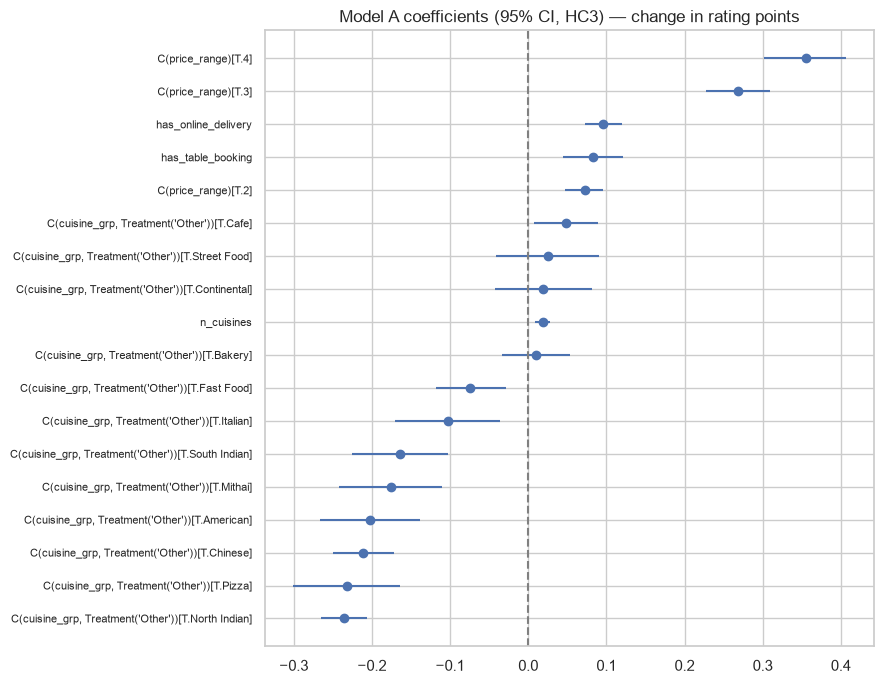

In [31]:
ct = coef_table(ols_a).loc[key[1:]].sort_values("coef")
fig, ax = plt.subplots(figsize=(9, 7))
ax.errorbar(ct.coef, range(len(ct)), xerr=[ct.coef - ct.ci_low, ct.ci_high - ct.coef], fmt="o")
ax.set_yticks(range(len(ct))); ax.set_yticklabels(ct.index, fontsize=8); ax.axvline(0, c="grey", ls="--")
ax.set_title("Model A coefficients (95% CI, HC3) — change in rating points"); plt.tight_layout()

## 3.4 Robustness: India only
This removes the currency and cross-market mixing.

In [32]:
india = prep(rated[rated.country == "India"])
f_in = base.replace(" + C(country, Treatment('India'))", "")
ols_in = smf.ols(f_in, data=india).fit(cov_type="HC3")
ols_in_v = smf.ols(f_in + " + log_votes", data=india).fit(cov_type="HC3")
print(f"India n = {len(india):,} | R² without votes = {ols_in.rsquared:.3f}, with votes = {ols_in_v.rsquared:.3f}")
keys_in = [i for i in ols_in.params.index if not i.startswith(("C(city_grp", "Intercept"))]
pd.concat({"All countries": coef_table(ols_a).reindex(keys_in), "India only": coef_table(ols_in).loc[keys_in]}, axis=1)

India n = 6,513 | R² without votes = 0.315, with votes = 0.487


All countries                       India only                      
                                                            coef ci_low ci_high      p       coef ci_low ci_high      p
C(price_range)[T.2]                                        0.072  0.047   0.096  0.000      0.070  0.044   0.095  0.000
C(price_range)[T.3]                                        0.268  0.228   0.309  0.000      0.306  0.260   0.352  0.000
C(price_range)[T.4]                                        0.355  0.302   0.407  0.000      0.386  0.327   0.446  0.000
C(cuisine_grp, Treatment('Other'))[T.Bakery]               0.010 -0.034   0.053  0.667      0.014 -0.031   0.060  0.544
C(cuisine_grp, Treatment('Other'))[T.Cafe]                 0.048  0.007   0.089  0.022      0.061  0.015   0.107  0.009
C(cuisine_grp, Treatment('Other'))[T.Chinese]             -0.211 -0.250  -0.172  0.000     -0.216 -0.257  -0.175  0.000
C(cuisine_grp, Treatment('Other'))[T.Continental]          0.019 -0.043   0.081  0.551      0.015 -0.050   0.079  0.659
C(cuisine_grp, Treatment('Other'))[T.Fast Food]           -0.074 -0.118  -0.029  0.001     -0.058 -0.104  -0.013  0.012
C(cuisine_grp, Treatment('Other'))[T.Italian]             -0.103 -0.170  -0.036  0.003     -0.125 -0.208  -0.041  0.003
C(cuisine_grp, Treatment('Other'))[T.Mithai]              -0.176 -0.242  -0.110  0.000     -0.169 -0.236  -0.101  0.000
C(cuisine_grp, Treatment('Other'))[T.Mughlai]                NaN    NaN     NaN    NaN     -0.119 -0.196  -0.041  0.003
C(cuisine_grp, Treatment('Other'))[T.North Indian]        -0.236 -0.265  -0.206  0.000     -0.229 -0.261  -0.198  0.000
C(cuisine_grp, Treatment('Other'))[T.Pizza]               -0.232 -0.301  -0.164  0.000     -0.238 -0.310  -0.166  0.000
C(cuisine_grp, Treatment('Other'))[T.South Indian]        -0.164 -0.225  -0.103  0.000     -0.153 -0.216  -0.090  0.000
C(cuisine_grp, Treatment('Other'))[T.Street Food]          0.025 -0.041   0.091  0.458      0.033 -0.035   0.101  0.340
has_online_delivery                                        0.096  0.072   0.120  0.000      0.096  0.073   0.120  0.000
has_table_booking                                          0.083  0.045   0.121  0.000      0.056  0.015   0.097  0.007
n_cuisines                                                 0.019  0.009   0.028  0.000      0.018  0.008   0.028  0.000

## 3.5 Conclusions
The numbers below are computed from the fitted models. The raw difference is before controls; A and B are the model coefficients without and with votes (* = p < 0.05).

In [33]:
rho = {c: stats.spearmanr(*rated[[c, "rating"]].dropna().T.values)[0] for c in ["log_votes", "price_range", "cost_usd", "n_cuisines"]}
raw_diff = {c: rated.groupby(c).rating.mean().diff().iloc[-1] for c in ["has_online_delivery", "has_table_booking"]}
def fmt(term):
    star = lambda r: "*" if r.pvalues[term] < .05 else ""
    return f"A {ols_a.params[term]:+.2f}{star(ols_a)}, B {ols_b.params[term]:+.2f}{star(ols_b)}"
cz = coef_table(ols_a)
cz = cz[cz.index.str.contains("cuisine_grp")].coef
name = lambda i: i.split("T.")[1].rstrip("]")

print(f'''Drivers of rating (rated restaurants, n = {len(rated):,}). Model coefficients are in rating points.

 1. Votes / popularity   rho = {rho["log_votes"]:.2f}; {ols_b.params["log_votes"]:+.2f} per log-unit of votes (B).
                         The strongest link, but causality runs both ways. Adding votes raises R² {ols_a.rsquared:.2f} -> {ols_b.rsquared:.2f}.
 2. Price range          rho = {rho["price_range"]:.2f}. Tier 4 vs tier 1: {fmt("C(price_range)[T.4]")}.
                         Most of the premium shrinks once votes is included, since pricier places also get more votes.
 3. Location             Big country/city differences (Kruskal-Wallis on city p ~ 0; see the fixed-effects table).
                         Mostly a sampling artefact: only Delhi NCR is fully listed, and other cities are about 20 curated picks (see Q5).
 4. Primary cuisine      Relative to 'Other': best {name(cz.idxmax())} ({cz.max():+.2f}), worst {name(cz.idxmin())} ({cz.min():+.2f}).
 5. Table booking        raw {raw_diff["has_table_booking"]:+.2f}; {fmt("has_table_booking")}.
 6. Online delivery      raw {raw_diff["has_online_delivery"]:+.2f}; {fmt("has_online_delivery")}.
                         Compare the raw sign with the adjusted sign. The raw gap reflects the mix of country and price.
 7. Number of cuisines   rho = {rho["n_cuisines"]:.2f}; {fmt("n_cuisines")}. Negligible.

Robustness: India-only R² = {ols_in.rsquared:.2f} without votes, with similar price and cuisine effects (see 3.4).

Caveats: the data is observational; {(~df.rated).mean():.0%} of restaurants are unrated and excluded; it is {(df.country=="India").mean():.0%} India
({(df.city=="New Delhi").mean():.0%} New Delhi); FX conversion is approximate; there is no review text, date or service-quality data.''')

Drivers of rating (rated restaurants, n = 7,403). Model coefficients are in rating points.

 1. Votes / popularity   rho = 0.68; +0.19 per log-unit of votes (B).
                         The strongest link, but causality runs both ways. Adding votes raises R² 0.43 -> 0.58.
 2. Price range          rho = 0.40. Tier 4 vs tier 1: A +0.35*, B +0.12*.
                         Most of the premium shrinks once votes is included, since pricier places also get more votes.
 3. Location             Big country/city differences (Kruskal-Wallis on city p ~ 0; see the fixed-effects table).
                         Mostly a sampling artefact: only Delhi NCR is fully listed, and other cities are about 20 curated picks (see Q5).
 4. Primary cuisine      Relative to 'Other': best Cafe (+0.05), worst North Indian (-0.24).
 5. Table booking        raw +0.17; A +0.08*, B +0.00.
 6. Online delivery      raw -0.09; A +0.10*, B -0.04*.
                         Compare the raw sign with the adjusted sign. The 

# Part 4 — Questions & answers
**Definitions used below**
* *Highly rated* = aggregate rating ≥ 4.5 (Zomato's "Excellent" band). *Very good or better* = ≥ 4.0.
* *Café* = "Cafe" is listed as a cuisine, or the name contains cafe/café/coffee.
* *Chains* are grouped by restaurant name (case and spacing ignored), so a chain appears only once. A chain's rating is the vote-weighted average across its branches.
* *Ranking* uses a **Bayesian (IMDb-style) score**: `score = v/(v+m)·R + m/(v+m)·C`. Here R is the chain's rating, v its total votes, C the vote-weighted mean rating, and m the median votes per restaurant. A 4.9 from 8 votes should not beat a 4.8 from 5,000 votes; this score pulls small-sample ratings toward the average.

In [34]:
CAFE = rated.cuisine_list.apply(lambda l: "Cafe" in l) | rated.restaurant_name.str.contains(r"caf|coffee", case=False)
rated["is_cafe"] = CAFE
rated["excellent"] = rated.rating >= 4.5
rated["very_good_plus"] = rated.rating >= 4.0

def by_city(d, min_n=20):
    t = d.groupby(["city", "country"]).agg(rated=("rating", "size"), excellent=("excellent", "sum"),
                                           very_good_plus=("very_good_plus", "sum"), mean_rating=("rating", "mean"))
    t["pct_excellent"] = (t.excellent / t.rated * 100).round(1)
    return t.round(2)

## Q1. Which city has the most highly rated restaurants / cafés?

In [35]:
t = by_city(rated)
print("By COUNT of excellent (>= 4.5) restaurants:")
display(t.sort_values(["excellent", "very_good_plus"], ascending=False).head(10))
print("By SHARE of excellent restaurants (cities with >= 20 rated):")
display(t[t.rated >= 20].sort_values("pct_excellent", ascending=False).head(10))

By COUNT of excellent (>= 4.5) restaurants:


,,rated,excellent,very_good_plus,mean_rating,pct_excellent
city,country,,,,,
New Delhi,India,4048,28,328,3.30,0.7
London,United Kingdom,20,15,19,4.54,75.0
Gurgaon,India,890,12,95,3.33,1.3
Rio de Janeiro,Brazil,19,11,19,4.49,57.9
Tampa Bay,United States,20,10,18,4.41,50.0
Orlando,United States,20,9,19,4.47,45.0
Rest of Hawaii,United States,20,9,19,4.41,45.0
Auckland,New Zealand,20,9,18,4.28,45.0
Bangalore,India,20,9,18,4.38,45.0


By SHARE of excellent restaurants (cities with >= 20 rated):


,,rated,excellent,very_good_plus,mean_rating,pct_excellent
city,country,,,,,
London,United Kingdom,20,15,19,4.54,75.0
Tampa Bay,United States,20,10,18,4.41,50.0
Bangalore,India,20,9,18,4.38,45.0
Auckland,New Zealand,20,9,18,4.28,45.0
Dubai,UAE,20,9,17,4.37,45.0
Rest of Hawaii,United States,20,9,19,4.41,45.0
Orlando,United States,20,9,19,4.47,45.0
Abu Dhabi,UAE,20,7,19,4.30,35.0
Des Moines,United States,20,6,18,4.24,30.0


In [36]:
tc = by_city(rated[rated.is_cafe])
print(f"Cafés: {rated.is_cafe.sum():,} rated, {rated[rated.is_cafe].excellent.sum()} excellent")
display(tc.sort_values(["excellent", "very_good_plus"], ascending=False).head(8))

Cafés: 946 rated, 54 excellent


,,rated,excellent,very_good_plus,mean_rating,pct_excellent
city,country,,,,,
New Delhi,India,461,9,85,3.52,2.0
Bangalore,India,7,4,7,4.47,57.1
Dubai,UAE,4,3,4,4.45,75.0
Guwahati,India,8,2,8,4.24,25.0
Auckland,New Zealand,7,2,6,3.99,28.6
Edinburgh,United Kingdom,8,2,5,4.18,25.0
İstanbul,Turkey,4,2,4,4.40,50.0
Rest of Hawaii,United States,3,2,3,4.40,66.7


In [37]:
a, b, c = t.excellent.idxmax(), t[t.rated >= 20].pct_excellent.idxmax(), tc.excellent.idxmax()
print(f"""ANSWER Q1
* Most excellent restaurants by count: {a[0]} ({t.loc[a, "excellent"]} of {t.loc[a, "rated"]:,} rated, only {t.loc[a, "pct_excellent"]}%).
* Highest share excellent: {b[0]} ({t.loc[b, "excellent"]}/{t.loc[b, "rated"]} = {t.loc[b, "pct_excellent"]}%).
* Cafés: {c[0]} has the most excellent cafés ({tc.loc[c, "excellent"]}).
The count leader wins on volume because the dataset is {(df.city == "New Delhi").mean():.0%} New Delhi. Most non-Indian cities have exactly
20 listings, so their high shares probably reflect a curated sample, not a better food scene (see Q5).""")

ANSWER Q1
* Most excellent restaurants by count: New Delhi (28 of 4,048 rated, only 0.7%).
* Highest share excellent: London (15/20 = 75.0%).
* Cafés: New Delhi has the most excellent cafés (9).
The count leader wins on volume because the dataset is 57% New Delhi. Most non-Indian cities have exactly
20 listings, so their high shares probably reflect a curated sample, not a better food scene (see Q5).


## Q2. Top 10 restaurants by rating, chains merged (world, then India)

In [38]:
def chain_table(d):
    d = d.assign(key=d.restaurant_name.str.strip().str.casefold().str.replace(r"\s+", " ", regex=True))
    g = d.groupby("key").apply(lambda x: pd.Series({
        "restaurant": x.restaurant_name.mode().iat[0],
        "branches": len(x),
        "rating": np.average(x.rating, weights=x.votes),
        "votes": x.votes.sum(),
        "cities": ", ".join(sorted(x.city.unique()))[:45],
        "country": ", ".join(sorted(x.country.unique())),
        "cuisines": ", ".join(pd.Series(x.cuisine_list.sum()).value_counts().index[:4]),
        "cost_usd": x.cost_usd.mean(),
    }), include_groups=False)
    C, m = np.average(d.rating, weights=d.votes), d.votes.median()
    g["score"] = g.votes / (g.votes + m) * g.rating + m / (g.votes + m) * C
    print(f"Prior: C = {C:.2f} (vote-weighted mean), m = {m:.0f} votes")
    return g.sort_values(["score", "votes"], ascending=False).reset_index(drop=True)

cols = ["restaurant", "branches", "rating", "votes", "score", "country", "cities", "cuisines", "cost_usd"]
world = chain_table(rated)
top10_world = world.head(10)
top10_world.index += 1
top10_world[cols].round(2)

Prior: C = 3.98 (vote-weighted mean), m = 60 votes


,restaurant,branches,rating,votes,score,country,cities,cuisines,cost_usd
1,Talaga Sampireun,3,4.9,5514,4.89,Indonesia,"Jakarta, Tangerang","Sunda, Indonesian",12.6
2,Mirchi And Mime,1,4.9,3244,4.88,India,Mumbai,"North Indian, South Indian, Mughlai",18.0
3,McGuire's Irish Pub & Brewery,1,4.9,2238,4.88,United States,Pensacola,"Burger, Bar Food, Steak",40.0
4,Indian Accent - The Manor,1,4.9,1934,4.87,India,New Delhi,Modern Indian,48.0
5,Pom Pom's Teahouse and Sandwicheria,1,4.9,1457,4.86,United States,Orlando,"American, Sandwich, Tea",25.0
6,Mazzaro's Italian Market,1,4.9,1424,4.86,United States,Tampa Bay,"Italian, Deli",10.0
7,Mr. Dunderbak's Biergarten and Marketplatz,1,4.9,1413,4.86,United States,Tampa Bay,"European, German",40.0
8,Tresind - Nassima Royal Hotel,1,4.9,1352,4.86,UAE,Dubai,Indian,136.0
9,Mama's Fish House,1,4.9,1343,4.86,United States,Rest of Hawaii,"Hawaiian, Seafood",70.0
10,Yellow Dog Eats,1,4.9,1252,4.86,United States,Orlando,"American, BBQ, Sandwich",35.0


In [39]:
india_rated = rated[rated.country == "India"]
india_chains = chain_table(india_rated)
top10_india = india_chains.head(10)
top10_india.index += 1
top10_india[cols].round(2)

Prior: C = 3.89 (vote-weighted mean), m = 49 votes


,restaurant,branches,rating,votes,score,country,cities,cuisines,cost_usd
1,Mirchi And Mime,1,4.90,3244,4.88,India,Mumbai,"North Indian, South Indian, Mughlai",18.0
2,Indian Accent - The Manor,1,4.90,1934,4.87,India,New Delhi,Modern Indian,48.0
3,Grandson of Tunday Kababi,1,4.90,1057,4.86,India,Lucknow,"Mughlai, Lucknowi",3.6
4,Naturals Ice Cream,2,4.87,3094,4.85,India,New Delhi,Ice Cream,1.8
5,Toit,1,4.80,10934,4.80,India,Bangalore,"Italian, American, Pizza",24.0
6,Sagar Gaire Fast Food,1,4.90,427,4.80,India,Bhopal,Fast Food,3.0
7,Masala Library,1,4.90,408,4.79,India,New Delhi,Modern Indian,60.0
8,Le Plaisir,1,4.80,2510,4.78,India,Pune,"European, Desserts",12.0
9,Prankster,1,4.80,1478,4.77,India,Gurgaon,"Modern Indian, North Indian",18.0
10,Spice Kraft,1,4.80,1424,4.77,India,Kolkata,"Continental, Middle Eastern, Asian",14.4


In [40]:
print("For comparison, the highest-rated multi-branch chains in India (>= 3 branches):")
india_chains[india_chains.branches >= 3].head(10)[cols].round(2)

For comparison, the highest-rated multi-branch chains in India (>= 3 branches):


,restaurant,branches,rating,votes,score,country,cities,cuisines,cost_usd
12,AB's - Absolute Barbecues,4,4.75,13400,4.74,India,"Bangalore, Chennai, Hyderabad","European, Mediterranean, North Indian",18.00
23,Chili's,5,4.60,8156,4.60,India,"Chandigarh, Chennai, Hyderabad, Pune","Mexican, American, Tex-Mex, Burger",20.40
44,Barbeque Nation,25,4.50,27835,4.50,India,"Bhubaneshwar, Chandigarh, Chennai, Coimbatore","North Indian, Chinese, Mediterranean, European",18.62
53,Big Chill,4,4.47,10853,4.47,India,New Delhi,"Italian, Continental, European, Cafe",18.00
66,Onesta,3,4.45,2821,4.44,India,Bangalore,"Pizza, Cafe, Italian",7.20
77,The Fisherman's Wharf,3,4.42,1022,4.40,India,"Goa, Hyderabad","Continental, Goan, Seafood, North Indian",14.80
105,Food Scouts,3,4.43,312,4.36,India,New Delhi,"North Indian, Chinese, Continental",8.40
120,Farzi Cafe,5,4.33,9189,4.33,India,"Bangalore, Gurgaon, Mumbai, New Delhi, Pune",Modern Indian,21.36
138,Mocha,7,4.29,3111,4.29,India,"Ahmedabad, Chandigarh, Guwahati, Indore, Luck","Cafe, Continental, Italian, Desserts",10.89
144,Palmshore,3,4.29,2228,4.28,India,Chennai,"North Indian, Mughlai, Chinese, South Indian",10.20


## Q3. India: which cuisine is most highly rated, based on the best restaurants?

Three views, because "most highly rated" can mean different things:
1. **Representation among the best.** How often a cuisine appears among the top 50 Indian restaurants by score, compared with its share of all Indian restaurants (lift > 1 means over-represented).
2. **Excellent rate.** The share of each cuisine's Indian restaurants rated ≥ 4.5.
3. **Average rating.** The mean rating for cuisines with ≥ 50 Indian restaurants.

In [41]:
# one row per chain, so a 25-branch chain counts once
share = lambda chains: chains.cuisines.str.split(", ").explode().value_counts(normalize=True)
ex_ind = india_rated.explode("cuisine_list")
q3 = pd.DataFrame({
    "n_restaurants": ex_ind.cuisine_list.value_counts(),
    "share_all_%": ex_ind.cuisine_list.value_counts(normalize=True) * 100,
    "share_top50_%": share(india_chains.head(50)) * 100,
    "excellent_%": ex_ind.groupby("cuisine_list").excellent.mean() * 100,
    "mean_rating": ex_ind.groupby("cuisine_list").rating.mean(),
}).fillna(0)
q3["lift_top50"] = q3["share_top50_%"] / q3["share_all_%"]
q3 = q3[q3.n_restaurants >= 50].round(2)
q3.sort_values("share_top50_%", ascending=False).head(12)

,n_restaurants,share_all_%,share_top50_%,excellent_%,mean_rating,lift_top50
North Indian,3003,20.81,11.45,1.43,3.29,0.55
Continental,687,4.76,9.16,4.08,3.70,1.92
Italian,644,4.46,7.63,3.73,3.71,1.71
American,216,1.50,6.87,7.87,3.55,4.59
Asian,181,1.25,6.11,7.73,3.85,4.87
Cafe,559,3.87,5.34,3.94,3.63,1.38
Chinese,2139,14.83,5.34,0.79,3.27,0.36
Mexican,124,0.86,4.58,8.06,3.83,5.33
European,117,0.81,3.82,11.11,3.91,4.71
Bakery,517,3.58,3.05,0.77,3.37,0.85


In [42]:
print("Ranked by excellent rate (cuisines with >= 50 Indian restaurants):")
q3.sort_values("excellent_%", ascending=False).head(10)

Ranked by excellent rate (cuisines with >= 50 Indian restaurants):


,n_restaurants,share_all_%,share_top50_%,excellent_%,mean_rating,lift_top50
Mediterranean,89,0.62,3.05,13.48,3.98,4.95
European,117,0.81,3.82,11.11,3.91,4.71
Mexican,124,0.86,4.58,8.06,3.83,5.33
American,216,1.50,6.87,7.87,3.55,4.59
Asian,181,1.25,6.11,7.73,3.85,4.87
Seafood,78,0.54,3.05,7.69,3.78,5.65
Burger,153,1.06,2.29,5.88,3.52,2.16
Ice Cream,159,1.10,0.76,5.03,3.41,0.69
Continental,687,4.76,9.16,4.08,3.70,1.92
Cafe,559,3.87,5.34,3.94,3.63,1.38


In [43]:
top_rep = q3.sort_values("share_top50_%", ascending=False).index[0]
over = q3[(q3["share_top50_%"] >= 4) & (q3.lift_top50 >= 2)].sort_values("lift_top50", ascending=False)
under = q3[(q3.n_restaurants >= 500) & (q3.lift_top50 < 1)].sort_values("lift_top50")
top_exc = q3["excellent_%"].idxmax()
top_mean = q3.mean_rating.idxmax()
print(f"""ANSWER Q3 (India)
* Appears most among the top 50: {top_rep} ({q3.loc[top_rep, "share_top50_%"]:.1f}% of cuisine mentions, vs {q3.loc[top_rep, "share_all_%"]:.1f}% overall, lift {q3.loc[top_rep, "lift_top50"]:.2f}).
* Over-represented among the top 50 (lift >= 2, share >= 4%): {", ".join(f"{c} ({r:.1f}x)" for c, r in over.lift_top50.items())}
* Under-represented mass cuisines (>= 500 restaurants, lift < 1): {", ".join(f"{c} ({r:.2f}x)" for c, r in under.lift_top50.items())}
* Highest excellent rate: {top_exc} ({q3.loc[top_exc, "excellent_%"]:.1f}% of its restaurants are >= 4.5); highest mean rating: {top_mean} ({q3.loc[top_mean, "mean_rating"]:.2f}).
So the most highly rated cuisine is {top_exc} by quality (rate and mean) and {top_rep} by presence. {top_rep} is common at the top only
because it is common everywhere. Niche international cuisines are small but far more likely to be excellent.""")

ANSWER Q3 (India)
* Appears most among the top 50: North Indian (11.4% of cuisine mentions, vs 20.8% overall, lift 0.55).
* Over-represented among the top 50 (lift >= 2, share >= 4%): Mexican (5.3x), Asian (4.9x), American (4.6x)
* Under-represented mass cuisines (>= 500 restaurants, lift < 1): Fast Food (0.29x), Chinese (0.36x), North Indian (0.55x), Mughlai (0.56x), Bakery (0.85x)
* Highest excellent rate: Mediterranean (13.5% of its restaurants are >= 4.5); highest mean rating: Mediterranean (3.98).
So the most highly rated cuisine is Mediterranean by quality (rate and mean) and North Indian by presence. North Indian is common at the top only
because it is common everywhere. Niche international cuisines are small but far more likely to be excellent.


In [44]:
# Caveat check: which restaurants are behind the top cuisine's excellent rate?
exc_top = ex_ind[(ex_ind.cuisine_list == top_exc) & ex_ind.excellent].restaurant_name.value_counts()
print(f"Excellent {top_exc} restaurants in India ({exc_top.sum()}):")
exc_top

Excellent Mediterranean restaurants in India (12):


restaurant_name
AB's - Absolute Barbecues            4
Barbeque Nation                      4
Nini's Kitchen                       1
Basil With A Twist                   1
Coal Barbecues                       1
La Quello - Mediterranean Kitchen    1
Name: count, dtype: int64

**Caveat.** Mediterranean's lead comes mostly from **barbecue-buffet chains** (AB's – Absolute Barbecues and Barbeque Nation) that list "Mediterranean" among their cuisines. It is not a result for stand-alone Mediterranean restaurants.
Counting each chain once, the robust answer is that **international / "fusion-casual" menus (Mexican, Asian, American, European, Continental) are over-represented among India's best restaurants**. North Indian, Chinese, Mughlai and Fast Food are under-represented relative to how common they are.

## Q4. Is India's most *preferred* cuisine (top 3) different from the cuisines of the top 10 restaurants?
Diners' preference can't be observed directly, so two proxies are used:
* **Supply**: the number of restaurants offering the cuisine. Restaurants open where there is demand.
* **Engagement**: total votes on restaurants offering it. More visits lead to more votes.

These are compared with the cuisines on the menus of the India top-10 (Q2).

In [45]:
ex_all_india = df[(df.country == "India")].explode("cuisine_list")   # includes unrated restaurants for supply
pref = pd.DataFrame({
    "restaurants_offering": ex_all_india.cuisine_list.value_counts(),
    "total_votes": ex_all_india.groupby("cuisine_list").votes.sum(),
    "top10_mentions": top10_india.cuisines.str.split(", ").explode().value_counts(),
}).fillna(0).astype(int)
pref["rank_supply"] = pref.restaurants_offering.rank(ascending=False, method="min").astype(int)
pref["rank_votes"] = pref.total_votes.rank(ascending=False, method="min").astype(int)
pref.sort_values("restaurants_offering", ascending=False).head(12)

,restaurants_offering,total_votes,top10_mentions,rank_supply,rank_votes
North Indian,3946,591053,2,1,1
Chinese,2690,351874,0,2,2
Fast Food,1963,180463,1,3,5
Mughlai,992,150715,2,4,7
Bakery,726,54427,0,5,17
Continental,724,282505,1,6,4
Italian,682,300431,1,7,3
South Indian,631,79772,1,8,11
Cafe,627,159432,0,9,6
Desserts,597,78904,1,10,12


In [46]:
top3_supply = pref.restaurants_offering.nlargest(3).index.tolist()
top3_votes = pref.total_votes.nlargest(3).index.tolist()
top10_cuis = pref.top10_mentions[pref.top10_mentions > 0].sort_values(ascending=False)
overlap = [c for c in top3_supply if c in top10_cuis.index]
print(f"""ANSWER Q4 (India)
* Most preferred by supply: {", ".join(top3_supply)}
* Most preferred by votes:  {", ".join(top3_votes)}
* Cuisines on the India top-10 menus: {", ".join(f"{c} ({n})" for c, n in top10_cuis.items())}
* Overlap between the supply top 3 and the top-10 menus: {", ".join(overlap) or "none"}
So yes, they differ. The top-rated restaurants are not simply the best versions of the most popular cuisine.""")

ANSWER Q4 (India)
* Most preferred by supply: North Indian, Chinese, Fast Food
* Most preferred by votes:  North Indian, Chinese, Italian
* Cuisines on the India top-10 menus: Modern Indian (3), Mughlai (2), North Indian (2), American (1), Asian (1), Continental (1), Desserts (1), European (1), Fast Food (1), Ice Cream (1), Italian (1), Lucknowi (1), Middle Eastern (1), Pizza (1), South Indian (1)
* Overlap between the supply top 3 and the top-10 menus: North Indian, Fast Food
So yes, they differ. The top-rated restaurants are not simply the best versions of the most popular cuisine.


In [47]:
comp = pd.DataFrame({
    "India top 10": top10_india[["rating", "votes", "cost_usd", "branches"]].median(),
    "All rated India": india_rated.assign(branches=1)[["rating", "votes", "cost_usd", "branches"]].median(),
})
comp.loc["price_range_mean"] = [india_rated.set_index(india_rated.restaurant_name.str.strip().str.casefold())
                                 .loc[top10_india.restaurant.str.strip().str.casefold()].price_range.mean(),
                                 india_rated.price_range.mean()]
comp.round(2)

,India top 10,All rated India
rating,4.88,3.30
votes,1706.00,49.00
cost_usd,16.20,6.00
branches,1.00,1.00
price_range_mean,2.55,1.88


**Why they differ, and how far your hypothesis holds.**
* **They overlap only partly.** North Indian is both the most preferred and on the top-10 menus. **Chinese, the #2 preference, is completely absent from the top 10.** The top 10 is still mostly Indian, but it is the *upscale or specialist* end: Modern Indian (Indian Accent, Masala Library, Prankster), Lucknowi/Mughlai kebabs (Tunday), and a single-product ice-cream shop.
* **Price and locality matter, but aren't everything.** The top 10's median cost is about 2.5× the Indian median, and its price tier is higher (table above), in line with Part 3. But three of the ten are budget places (Tunday, Naturals, Sagar Gaire, each under $4 for two). A cheap specialist that does one thing well can rate as high as fine dining.
* **Consistency.** All the India top 10 are single sites except Naturals (2 branches). The best 3+ branch chains (Q2 table) peak at 4.75 and mostly sit at 4.3–4.6. Keeping ratings high across branches is harder.
* **Preference shows up as volume, not stars.** North Indian, Chinese and Fast Food dominate supply and votes because they are everyday, affordable, delivery-friendly food. Those cuisines have *below-average* ratings (Q3 lift < 1; negative coefficients in Model A). Ratings reward how well a restaurant does something, not how much people want that cuisine. This supports your point.

## Q5. Other observations

In [48]:
non_india = df[df.country != "India"]
city_sizes = non_india.groupby("city").size()
chain_flag = rated.restaurant_name.str.strip().str.casefold().map(
    rated.restaurant_name.str.strip().str.casefold().value_counts()) > 1
NCR = ["New Delhi", "Gurgaon", "Noida", "Faridabad", "Ghaziabad"]
in_sizes = df[(df.country == "India") & ~df.city.isin(NCR)].groupby("city").size()
obs = {
    "Non-India cities with exactly 20 listings": f"{(city_sizes == 20).sum()} of {len(city_sizes)} cities ({city_sizes[city_sizes == 20].sum()} rows)",
    "Indian cities outside Delhi NCR": f"{len(in_sizes)} cities, median {in_sizes.median():.0f} listings each (NCR: {df.city.isin(NCR).sum():,})",
    "Votes on unrated restaurants": f"max {df[~df.rated].votes.max()}; the lowest vote count on any rated one is {rated.votes.min()}",
    "Mean rating: India vs rest": f"{rated[rated.country == 'India'].rating.mean():.2f} vs {rated[rated.country != 'India'].rating.mean():.2f}",
    "Unrated share: India vs rest": f"{(~df[df.country == 'India'].rated).mean():.0%} vs {(~non_india.rated).mean():.0%}",
    "Median votes: unrated vs rated": f"{df[~df.rated].votes.median():.0f} vs {rated.votes.median():.0f}",
    "Mean rating: chain branch vs independent": f"{rated[chain_flag].rating.mean():.2f} vs {rated[~chain_flag].rating.mean():.2f}",
    "Online delivery by price range 1/2/3/4 (%)": " / ".join(f"{v:.0f}" for v in df.groupby("price_range").has_online_delivery.mean() * 100),
    "Table booking by price range 1/2/3/4 (%)": " / ".join(f"{v:.0f}" for v in df.groupby("price_range").has_table_booking.mean() * 100),
    "Restaurants 'delivering now'": f"{df.is_delivering_now.sum()} ({df.is_delivering_now.mean():.1%})",
    "Rating range (rated)": f"{rated.rating.min()} – {rated.rating.max()}; {rated.rating.between(3, 4).mean():.0%} fall between 3.0 and 4.0",
    "Delhi NCR mean rating vs other Indian cities": (lambda ncr: f"{rated[rated.country == 'India'][ncr].rating.mean():.2f} vs {rated[rated.country == 'India'][~ncr].rating.mean():.2f}")(
        rated[rated.country == "India"].city.isin(["New Delhi", "Gurgaon", "Noida", "Faridabad", "Ghaziabad"])),
}
pd.Series(obs, name="value").to_frame()

,value
Non-India cities with exactly 20 listings,39 of 98 cities (780 rows)
Indian cities outside Delhi NCR,"38 cities, median 20 listings each (NCR: 7,947)"
Votes on unrated restaurants,max 3; the lowest vote count on any rated one ...
Mean rating: India vs rest,3.35 vs 4.08
Unrated share: India vs rest,25% vs 1%
Median votes: unrated vs rated,0 vs 60
Mean rating: chain branch vs independent,3.35 vs 3.48
Online delivery by price range 1/2/3/4 (%),16 / 41 / 29 / 9
Table booking by price range 1/2/3/4 (%),0 / 8 / 46 / 47
Restaurants 'delivering now',34 (0.4%)


**Takeaways**
1. **Only Delhi NCR is fully listed. Every other city is a sample of about 20.** This applies to foreign cities *and* to Indian cities such as Bangalore, Mumbai and Chennai. Those samples look like curated "top picks". They rate 4.0–4.5 on average, while Delhi NCR's full list, including every budget outlet, averages about 3.3. **This is the biggest finding about the dataset.** The city and country effects in Part 3 and the city rankings in Q1 mostly reflect *how the data was collected*, not food quality. Compare cities only within NCR, or only among the 20-listing cities.
2. **"Not rated" means too few votes.** Every unrated restaurant has 0–3 votes, and every rated one has at least 4. Zomato evidently shows no rating until a restaurant has 4 votes. These are new or obscure places, not bad ones. Treating rating 0 as a score would badly bias any average.
3. **Following from 1:** Delhi NCR's lower mean is a full-population average compared against curated samples. It is not evidence that Delhi's restaurants are worse.
4. **Chain branches rate slightly lower than independents on the raw numbers**, which fits the idea that consistency across branches is hard. Part of the gap comes from chains being concentrated in NCR.
5. **Service features follow price.** Table booking is almost only a feature of expensive restaurants. Online delivery peaks in the mid-price tiers. Neither is a quality signal once price is accounted for (Part 3).
6. **`is_delivering_now` is a snapshot** taken at scrape time, so it is not a restaurant attribute and shouldn't be modelled.
7. **Ratings are compressed.** Most sit between 3 and 4, so a 0.2-star effect is meaningful.

# Part 5 — NCR influence
Delhi NCR (New Delhi, Gurgaon, Noida, Faridabad, Ghaziabad) is the only fully listed region. Every other city is a sample of about 20 restaurants.
This section measures how much NCR drives the Part 4 answers. It then repeats Q1–Q4 **inside NCR only**, which is the one part of the data without the curated-sampling bias.

*Note on momos:* Zomato has no "Momos" cuisine tag. Momo outlets are tagged Chinese (or occasionally Tibetan), so they add to Chinese's counts and can't be separated.

In [49]:
df["ncr"] = df.city.isin(NCR)
rated["ncr"] = rated.city.isin(NCR)
ind = df[df.country == "India"]
ind_r = rated[rated.country == "India"]
pd.Series({
    "NCR restaurants": f"{df.ncr.sum():,}",
    "% of whole dataset": f"{df.ncr.mean():.1%}",
    "% of India": f"{ind.ncr.mean():.1%}",
    "% of rated India": f"{ind_r.ncr.mean():.1%}",
    "% of India votes": f"{ind[ind.ncr].votes.sum() / ind.votes.sum():.1%}",
    "% of India excellent (>= 4.5)": f"{ind_r[ind_r.excellent].ncr.mean():.1%}",
    "Rest of India": f"{(~ind.ncr).sum():,} restaurants in {ind[~ind.ncr].city.nunique()} cities",
}, name="value").to_frame()

,value
NCR restaurants,"7,947"
% of whole dataset,83.2%
% of India,91.9%
% of rated India,89.2%
% of India votes,71.0%
% of India excellent (>= 4.5),37.1%
Rest of India,705 restaurants in 38 cities


## 5.1 Cuisine preference: NCR vs rest of India

In [50]:
def pref_table(d):
    e = d.explode("cuisine_list")
    return pd.DataFrame({"%_offering": e.cuisine_list.value_counts() / len(d) * 100,
                         "votes": e.groupby("cuisine_list").votes.sum()})

p_ncr, p_rest = pref_table(ind[ind.ncr]), pref_table(ind[~ind.ncr])
cmp = p_ncr.join(p_rest, lsuffix="_NCR", rsuffix="_rest", how="outer").fillna(0)
cmp["rank_offer_NCR"] = cmp["%_offering_NCR"].rank(ascending=False, method="min").astype(int)
cmp["rank_offer_rest"] = cmp["%_offering_rest"].rank(ascending=False, method="min").astype(int)
cmp.sort_values("%_offering_NCR", ascending=False).head(12).round(1)

,%_offering_NCR,votes_NCR,%_offering_rest,votes_rest,rank_offer_NCR,rank_offer_rest
cuisine_list,,,,,,
North Indian,45.3,415661.0,49.5,175392.0,1,1
Chinese,30.8,257000.0,34.3,94874.0,2,2
Fast Food,23.5,157685.0,13.8,22778.0,3,6
Mughlai,11.7,122464.0,8.4,28251.0,4,8
Bakery,8.8,41160.0,4.1,13267.0,5,16
South Indian,7.2,55946.0,8.8,23826.0,6,7
Continental,6.9,189928.0,25.1,92577.0,7,3
Desserts,6.8,47417.0,7.8,31487.0,8,9
Street Food,6.8,36176.0,2.3,6004.0,9,20


In [51]:
print("Top 3 by supply  — NCR:", p_ncr["%_offering"].nlargest(3).index.tolist(), "| rest:", p_rest["%_offering"].nlargest(3).index.tolist())
print("Top 3 by votes   — NCR:", p_ncr.votes.nlargest(3).index.tolist(), "| rest:", p_rest.votes.nlargest(3).index.tolist())

Top 3 by supply  — NCR: ['North Indian', 'Chinese', 'Fast Food'] | rest: ['North Indian', 'Chinese', 'Continental']
Top 3 by votes   — NCR: ['North Indian', 'Chinese', 'Italian'] | rest: ['North Indian', 'Chinese', 'Continental']


## 5.2 Same cuisine, different region: is the rating gap about cuisine or about sampling?

In [52]:
e_r = ind_r.explode("cuisine_list")
top_c = e_r.cuisine_list.value_counts().head(10).index
gap = e_r[e_r.cuisine_list.isin(top_c)].pivot_table(index="cuisine_list", columns="ncr", values="rating", aggfunc=["mean", "size"])
gap.columns = ["mean_rest", "mean_NCR", "n_rest", "n_NCR"]
gap["gap_rest_minus_NCR"] = gap.mean_rest - gap.mean_NCR
gap.sort_values("n_NCR", ascending=False).round(2)

,mean_rest,mean_NCR,n_rest,n_NCR,gap_rest_minus_NCR
cuisine_list,,,,,
North Indian,3.88,3.22,349,2654,0.66
Chinese,3.84,3.20,242,1897,0.64
Fast Food,3.81,3.21,97,1443,0.60
Mughlai,3.90,3.22,59,732,0.68
Continental,3.97,3.60,177,510,0.37
Italian,4.03,3.61,147,497,0.41
Bakery,4.10,3.32,29,488,0.78
Desserts,4.07,3.43,55,432,0.64
Cafe,4.01,3.50,136,423,0.50


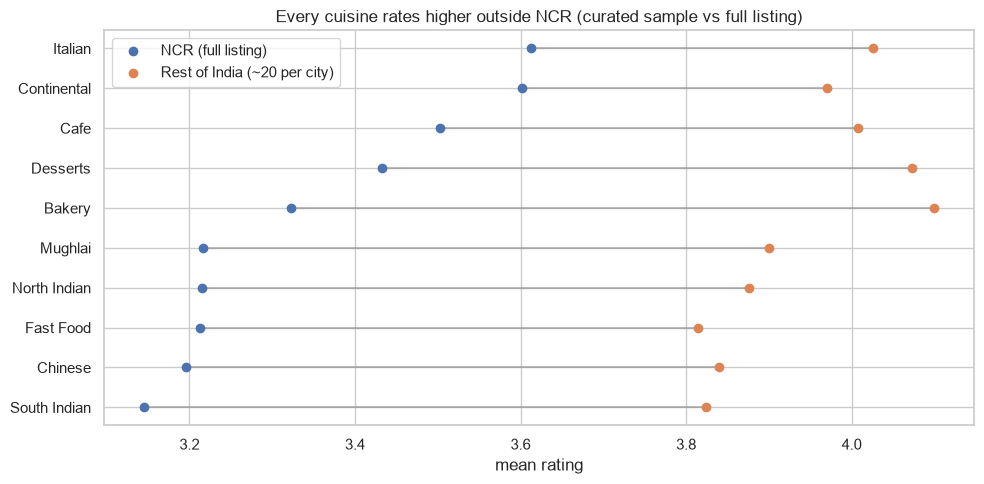

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
g = gap.sort_values("mean_NCR")
ax.hlines(range(len(g)), g.mean_NCR, g.mean_rest, color="grey", alpha=.5)
ax.scatter(g.mean_NCR, range(len(g)), label="NCR (full listing)", zorder=3)
ax.scatter(g.mean_rest, range(len(g)), label="Rest of India (~20 per city)", zorder=3)
ax.set_yticks(range(len(g))); ax.set_yticklabels(g.index); ax.set_xlabel("mean rating"); ax.legend()
ax.set_title("Every cuisine rates higher outside NCR (curated sample vs full listing)"); plt.tight_layout()

In [54]:
print(f"Gap (rest - NCR) across the top-10 cuisines: mean {gap.gap_rest_minus_NCR.mean():.2f}, "
      f"range {gap.gap_rest_minus_NCR.min():.2f} to {gap.gap_rest_minus_NCR.max():.2f}")
print(f"Spearman rank correlation of cuisine means NCR vs rest: {stats.spearmanr(gap.mean_NCR, gap.mean_rest)[0]:.2f}")

Gap (rest - NCR) across the top-10 cuisines: mean 0.60, range 0.37 to 0.78
Spearman rank correlation of cuisine means NCR vs rest: 0.76


## 5.3 Q1–Q4 re-run inside NCR only

In [55]:
ncr_r = rated[rated.ncr]
t_ncr = by_city(ncr_r)
t_ncr["pct_very_good_plus"] = (t_ncr.very_good_plus / t_ncr.rated * 100).round(1)
print("Q1 (NCR) — by city:")
display(t_ncr.sort_values("excellent", ascending=False))
tc_ncr = by_city(ncr_r[ncr_r.is_cafe]); tc_ncr["pct_very_good_plus"] = (tc_ncr.very_good_plus / tc_ncr.rated * 100).round(1)
print("Q1 (NCR) — cafés:")
display(tc_ncr.sort_values("excellent", ascending=False))

Q1 (NCR) — by city:


,,rated,excellent,very_good_plus,mean_rating,pct_excellent,pct_very_good_plus
city,country,,,,,,
New Delhi,India,4048,28,328,3.30,0.7,8.1
Gurgaon,India,890,12,95,3.33,1.3,10.7
Noida,India,696,2,29,3.16,0.3,4.2
Faridabad,India,151,1,4,3.10,0.7,2.6
Ghaziabad,India,23,0,0,3.10,0.0,0.0


Q1 (NCR) — cafés:


,,rated,excellent,very_good_plus,mean_rating,pct_excellent,pct_very_good_plus
city,country,,,,,,
New Delhi,India,461,9,85,3.52,2.0,18.4
Faridabad,India,15,1,2,3.27,6.7,13.3
Ghaziabad,India,4,0,0,3.45,0.0,0.0
Gurgaon,India,95,0,17,3.53,0.0,17.9
Noida,India,78,0,5,3.27,0.0,6.4


In [56]:
print("Q2 (NCR) — top 10 restaurants, chains merged:")
ncr_chains = chain_table(ncr_r)
top10_ncr = ncr_chains.head(10); top10_ncr.index += 1
top10_ncr[cols].round(2)

Q2 (NCR) — top 10 restaurants, chains merged:


Prior: C = 3.74 (vote-weighted mean), m = 40 votes


,restaurant,branches,rating,votes,score,country,cities,cuisines,cost_usd
1,Indian Accent - The Manor,1,4.90,1934,4.88,India,New Delhi,Modern Indian,48.0
2,Naturals Ice Cream,2,4.87,3094,4.85,India,New Delhi,Ice Cream,1.8
3,Masala Library,1,4.90,408,4.80,India,New Delhi,Modern Indian,60.0
4,Prankster,1,4.80,1478,4.77,India,Gurgaon,"Modern Indian, North Indian",18.0
5,Caterspoint,1,4.90,223,4.72,India,Gurgaon,"Mexican, American, Healthy Food",6.0
6,Echoes Satyaniketan,1,4.70,1563,4.68,India,New Delhi,"Cafe, Continental, Italian, Mexican",7.2
7,Manhattan Brewery & Bar Exchange,1,4.60,2093,4.58,India,Gurgaon,"Finger Food, American, Continental, North Indian",24.0
8,The California Boulevard,1,4.60,1691,4.58,India,New Delhi,"American, Asian, European, Seafood",24.0
9,Pa Pa Ya,1,4.70,268,4.58,India,New Delhi,"Asian, Chinese, Thai, Japanese",24.0
10,Cafeteria & Co.,1,4.60,1136,4.57,India,New Delhi,"Continental, Mexican",10.8


In [57]:
e_n = ncr_r.explode("cuisine_list")
q3n = pd.DataFrame({
    "n_restaurants": e_n.cuisine_list.value_counts(),
    "share_all_%": e_n.cuisine_list.value_counts(normalize=True) * 100,
    "share_top50_%": share(ncr_chains.head(50)) * 100,
    "very_good_plus_%": e_n.groupby("cuisine_list").very_good_plus.mean() * 100,
    "excellent_%": e_n.groupby("cuisine_list").excellent.mean() * 100,
    "mean_rating": e_n.groupby("cuisine_list").rating.mean(),
}).fillna(0)
q3n["lift_top50"] = q3n["share_top50_%"] / q3n["share_all_%"]
q3n = q3n[q3n.n_restaurants >= 50].round(2)
print("Q3 (NCR) — cuisines ranked by % rated >= 4.0 (min 50 restaurants):")
q3n.sort_values("very_good_plus_%", ascending=False).head(12)

Q3 (NCR) — cuisines ranked by % rated >= 4.0 (min 50 restaurants):


,n_restaurants,share_all_%,share_top50_%,very_good_plus_%,excellent_%,mean_rating,lift_top50
European,85,0.68,2.44,40.00,4.71,3.79,3.61
Asian,146,1.16,4.88,39.04,5.48,3.80,4.20
Mexican,74,0.59,4.07,32.43,5.41,3.70,6.91
Mediterranean,59,0.47,0.81,25.42,0.00,3.78,1.73
Italian,497,3.95,11.38,23.74,2.01,3.61,2.88
Continental,510,4.05,10.57,23.73,2.55,3.60,2.61
American,184,1.46,6.50,21.20,3.80,3.46,4.45
Seafood,50,0.40,0.81,20.00,2.00,3.59,2.05
Lebanese,53,0.42,0.81,18.87,1.89,3.55,1.93
Japanese,74,0.59,1.63,17.57,2.70,3.61,2.76


In [58]:
print("Q3 (NCR) — the mass-market cuisines:")
q3n.loc[[c for c in ["North Indian", "Chinese", "Fast Food", "Mughlai", "Street Food", "Bakery"] if c in q3n.index]]

Q3 (NCR) — the mass-market cuisines:


,n_restaurants,share_all_%,share_top50_%,very_good_plus_%,excellent_%,mean_rating,lift_top50
North Indian,2654,21.10,17.07,6.44,0.53,3.22,0.81
Chinese,1897,15.08,6.50,5.27,0.37,3.20,0.43
Fast Food,1443,11.47,0.81,3.88,0.21,3.21,0.07
Mughlai,732,5.82,2.44,5.87,0.27,3.22,0.42
Street Food,379,3.01,0.00,3.17,0.00,3.23,0.00
Bakery,488,3.88,0.81,6.76,0.20,3.32,0.21


In [59]:
top10n_cuis = top10_ncr.cuisines.str.split(", ").explode().value_counts()
top3n = p_ncr["%_offering"].nlargest(3).index.tolist()
best_n = q3n.sort_values("very_good_plus_%", ascending=False).index[:3].tolist()
print(f"""NCR-ONLY ANSWERS
Q1  Most excellent: {t_ncr.excellent.idxmax()[0]} ({t_ncr.excellent.max()}); highest % >= 4.0: {t_ncr.pct_very_good_plus.idxmax()[0]} ({t_ncr.pct_very_good_plus.max()}%).
    Cafés: most excellent in {tc_ncr.excellent.idxmax()[0]} ({tc_ncr.excellent.max()}).
Q2  #1 in NCR: {top10_ncr.restaurant.iat[0]} ({top10_ncr.rating.iat[0]:.2f} from {top10_ncr.votes.iat[0]:,} votes). See table for the full top 10.
Q3  Most highly rated cuisines (% >= 4.0): {", ".join(f"{c} ({q3n.loc[c, 'very_good_plus_%']:.0f}%)" for c in best_n)}
    vs North Indian {q3n.loc["North Indian", "very_good_plus_%"]:.0f}%, Chinese {q3n.loc["Chinese", "very_good_plus_%"]:.0f}%.
Q4  Most preferred (supply): {", ".join(top3n)}.
    NCR top-10 menus: {", ".join(f"{c} ({n})" for c, n in top10n_cuis.items())}
    Preferred top-3 on those menus: {", ".join(c for c in top3n if c in top10n_cuis.index) or "none"}.""")

NCR-ONLY ANSWERS
Q1  Most excellent: New Delhi (28); highest % >= 4.0: Gurgaon (10.7%).
    Cafés: most excellent in New Delhi (9).
Q2  #1 in NCR: Indian Accent - The Manor (4.90 from 1,934 votes). See table for the full top 10.
Q3  Most highly rated cuisines (% >= 4.0): European (40%), Asian (39%), Mexican (32%)
    vs North Indian 6%, Chinese 5%.
Q4  Most preferred (supply): North Indian, Chinese, Fast Food.
    NCR top-10 menus: Modern Indian (3), Mexican (3), American (3), Continental (3), North Indian (2), Asian (2), Ice Cream (1), Healthy Food (1), Cafe (1), Italian (1), Finger Food (1), European (1), Seafood (1), Chinese (1), Thai (1), Japanese (1)
    Preferred top-3 on those menus: North Indian, Chinese.


## 5.4 How NCR changes the Part 4 answers
| Q | Effect of NCR | Verdict |
|---|---|---|
| **Q1** | New Delhi tops the count only because it has thousands of listings. The cities that top the share ranking are curated samples of ~20. | The India-wide/world answer is **not a fair comparison**. Use the within-NCR table (5.3) or compare only the 20-listing cities with each other. |
| **Q2** | Most of the India top 10 comes from the 705 non-NCR restaurants, which are pre-selected favourites. | Valid as a list of top-rated places, but **NCR is under-represented relative to its size**. 5.3 gives NCR's own top 10. |
| **Q3** | The base rate (share of all Indian restaurants) is ~90% NCR, which inflates the "lift" of international cuisines. | **The direction holds inside NCR**: international and casual-dining cuisines rate far higher than North Indian, Chinese, Fast Food and Mughlai. The size of the lift was overstated. |
| **Q4** | NCR adds **Fast Food and Mughlai** to the preference list. North Indian and Chinese lead in *both* regions. | **Conclusion holds, with nuance.** In NCR's top 10, North Indian appears twice (next to Modern Indian), Chinese once (inside a pan-Asian menu) and Fast Food never. The top NCR restaurants are led by Modern Indian, Mexican, American and Continental menus. |
| **Q5** | Already about NCR / sampling. | — |

**Key point (5.2):** *every* cuisine rates higher outside NCR, by about 0.4–0.8 stars, and cuisines rank in broadly the same order (rank correlation ≈ 0.76).
Because the gap applies to every cuisine, it is mainly **sampling** (every NCR outlet vs hand-picked elsewhere), not Delhi taste. The gap is smallest for Continental and Italian (≈ 0.4). In NCR these are already mostly sit-down, mid-to-upscale places, closer to the curated profile. The mass cuisines (North Indian, Chinese, Fast Food, Mughlai) carry NCR's long tail of cheap outlets, so their gap is ≈ 0.6–0.7. The within-NCR results are the most reliable test of the idea that ratings reflect the restaurant (price, locality, consistency) while cuisine choice reflects preference.